# NHAMCS 2018-2022 Full EDA
This notebook delivers a publication-ready exploratory data analysis for ED triage dynamics, wait times, temporal trends, and bias diagnostics.

All visual outputs are exported to the plot folder with deterministic file names for project writeup use.

## Analysis Principles
- One visualization per EDA code cell
- Explicit missingness and class-imbalance checks
- Comparison-first design across demographic, clinical, and operational features
- Trend and fairness-oriented interpretation

In [31]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Global visual style for consistent, publication-ready figures
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "semibold"

DATA_PATH = Path("nhamcs_data_2018_22.csv")
PLOT_DIR = Path("plot")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded shape: {df.shape}")
display(df.head(3))

Loaded shape: (58124, 49)


,visit_month,day_of_week,arrival_time,ems_arrival,vitals_during_visit,age,residence,sex,insurance,no_payment,...,hist_sleep_apnea,hist_osteoporosis,hist_substance_abuse,intervention_iv_fluids,target_triage_acuity,wait_time_minutes,race,year,chief_complaint_text,injury_cause_text
0,12,1,2046.0,No,1.0,5,Private residence,Male,Unknown/Blank,0,...,0,0,0,0,4,21.0,Unknown/Other,2018,fever. throat soreness,Blank/Unknown
1,12,1,1907.0,No,1.0,5,Private residence,Female,Unknown/Blank,0,...,0,0,0,0,4,12.0,Unknown/Other,2018,"injury, other and unspecified, of foo.... foot...",other foreign body or object entering through ...
2,12,6,1435.0,No,1.0,0,Unknown,Male,Unknown/Blank,0,...,0,0,0,0,4,21.0,Unknown/Other,2018,fever. cough,Blank/Unknown


In [32]:
def save_and_show(fig, filename: str):
    out_path = PLOT_DIR / filename
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()

def arrival_hour_from_hhmm(value):
    if pd.isna(value):
        return np.nan
    try:
        ivalue = int(value)
    except (TypeError, ValueError):
        return np.nan
    hour = ivalue // 100
    if 0 <= hour <= 23:
        return hour
    return np.nan

df["arrival_hour"] = df["arrival_time"].apply(arrival_hour_from_hhmm)
df["wait_time_minutes_clipped"] = df["wait_time_minutes"].clip(
    upper=df["wait_time_minutes"].quantile(0.99)
 )

df["age_group"] = pd.cut(
    df["age"],
    bins=[-0.1, 17, 34, 49, 64, 79, 120],
    labels=["0-17", "18-34", "35-49", "50-64", "65-79", "80+"],
)

acuity_map = {1: "1-Immediate", 2: "2-Emergent", 3: "3-Urgent", 4: "4-Semi-urgent", 5: "5-Non-urgent"}
df["acuity_label"] = df["target_triage_acuity"].map(acuity_map)

hist_cols = [c for c in df.columns if c.startswith("hist_")]
df["comorbidity_count"] = df[hist_cols].fillna(0).sum(axis=1)
df["high_acuity_flag"] = (df["target_triage_acuity"] <= 2).astype(int)

print(f"Prepared derived columns. Plot export folder: {PLOT_DIR.resolve()}")

Prepared derived columns. Plot export folder: E:\kaggle\traigegeist\plot


## 1) Data Quality and Outcome Foundations
This section quantifies missingness, class imbalance, and wait-time distribution structure before deeper comparisons.

### Chart 1: Missingness profile
This plot identifies where data completeness can bias interpretation and where careful handling is required.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\3334113298.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="crest", ax=ax)


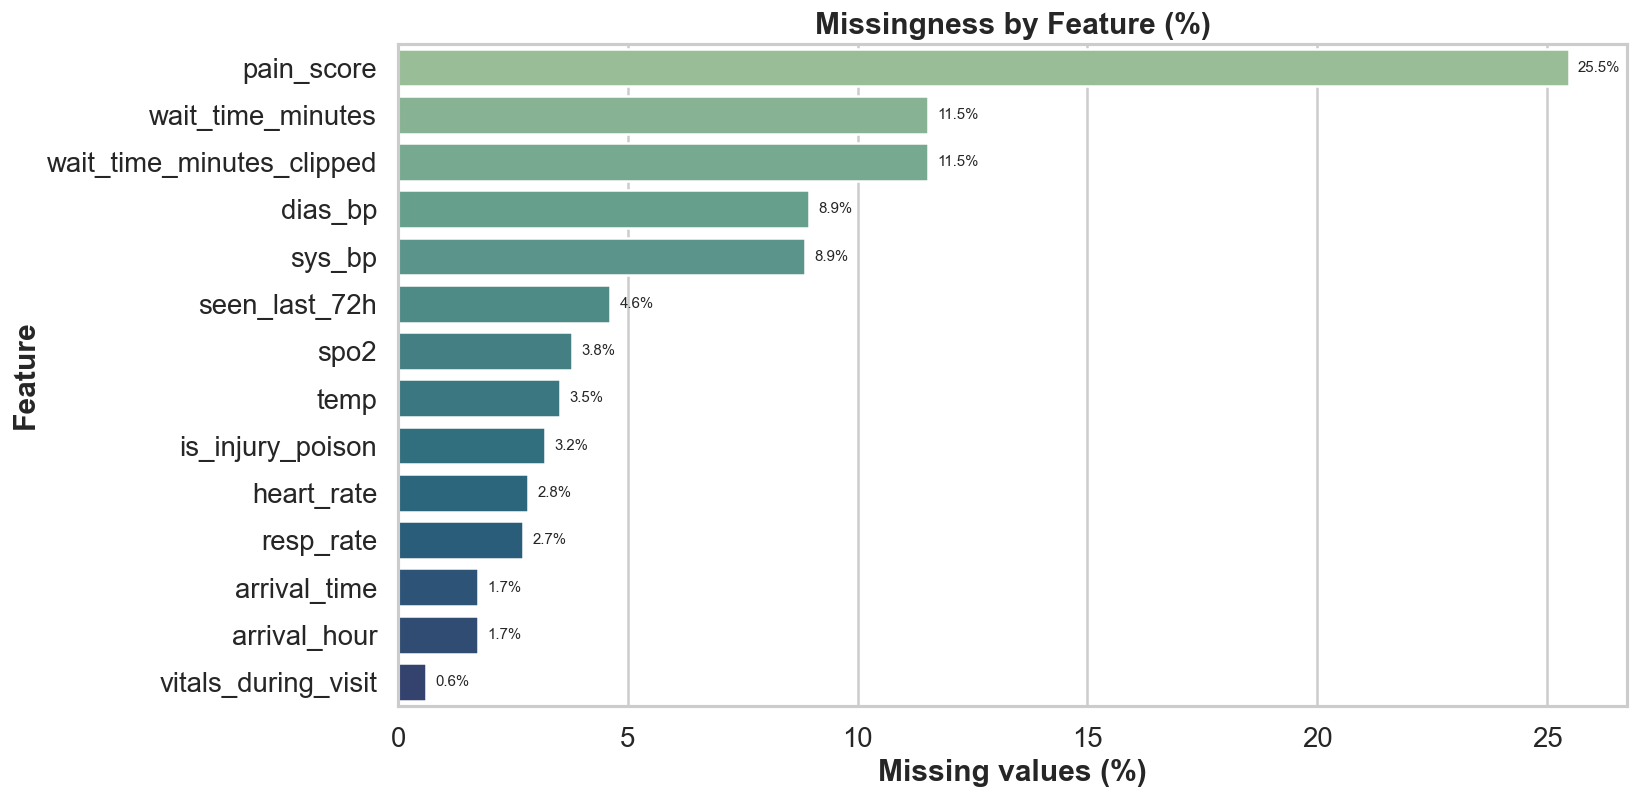

In [33]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="crest", ax=ax)
ax.set_title("Missingness by Feature (%)")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Feature")

for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)

save_and_show(fig, "01_missingness_profile.png")

### Chart 2: Triage acuity class distribution
Acuity class imbalance directly affects both modeling and interpretation of emergency severity trends.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\336724130.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acuity_counts.index.astype(str), y=acuity_counts.values, palette="mako", ax=ax)


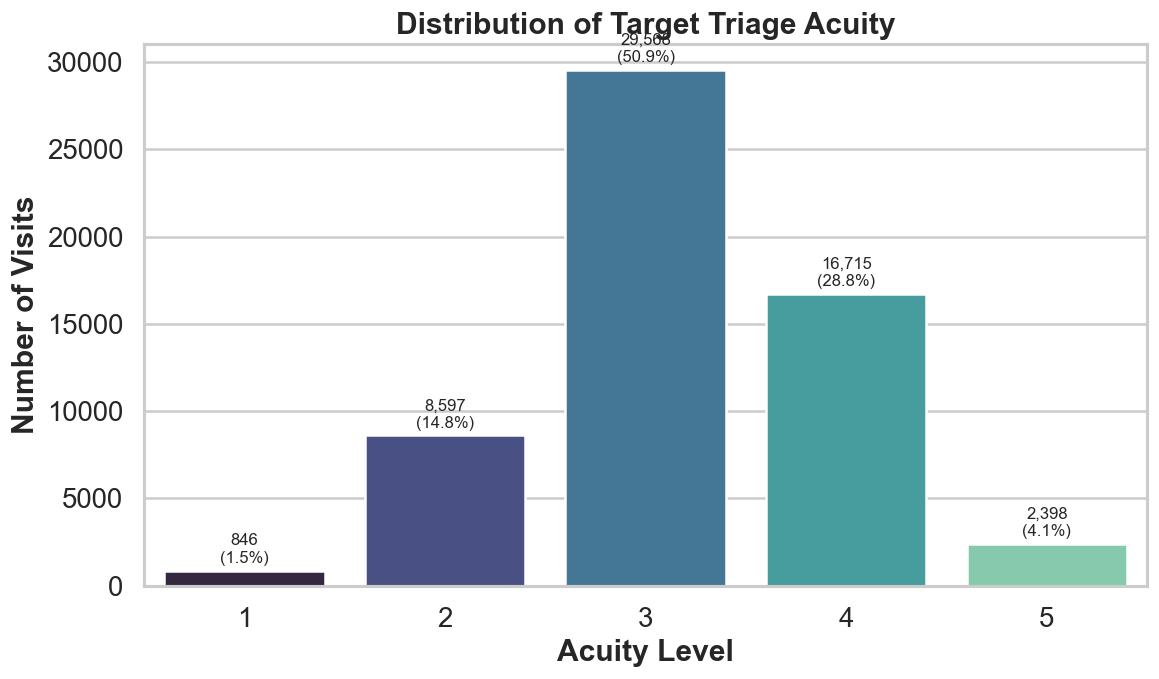

In [34]:
acuity_counts = df["target_triage_acuity"].value_counts().sort_index()
acuity_pct = acuity_counts / acuity_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=acuity_counts.index.astype(str), y=acuity_counts.values, palette="mako", ax=ax)
ax.set_title("Distribution of Target Triage Acuity")
ax.set_xlabel("Acuity Level")
ax.set_ylabel("Number of Visits")

for i, (count, pct) in enumerate(zip(acuity_counts.values, acuity_pct.values)):
    ax.text(i, count + acuity_counts.max() * 0.01, f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

save_and_show(fig, "02_acuity_distribution.png")

### Chart 3: Wait-time distribution with long-tail handling
Wait time is right-skewed, so this uses 99th-percentile clipping for readability while preserving operational interpretation.

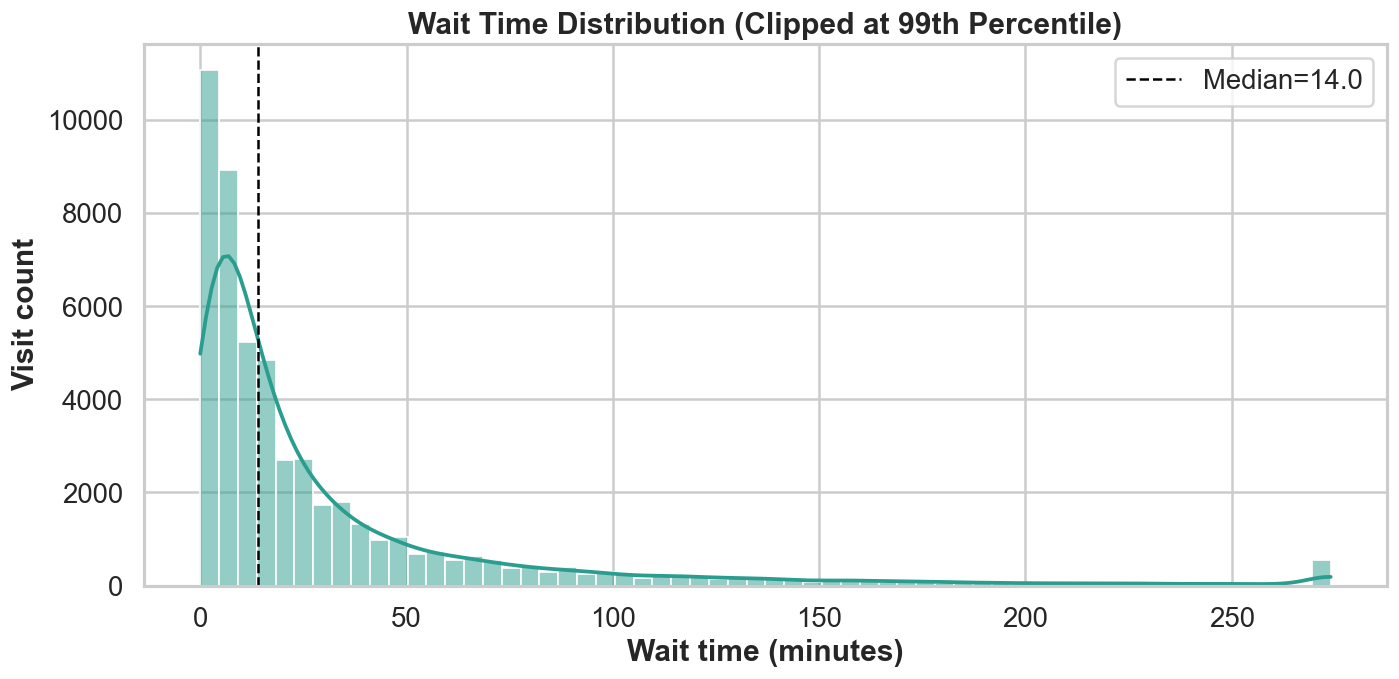

In [35]:
wait_q99 = df["wait_time_minutes"].quantile(0.99)
plot_wait = df["wait_time_minutes"].clip(upper=wait_q99).dropna()

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(plot_wait, bins=60, kde=True, color="#2a9d8f", ax=ax)
ax.set_title("Wait Time Distribution (Clipped at 99th Percentile)")
ax.set_xlabel("Wait time (minutes)")
ax.set_ylabel("Visit count")
ax.axvline(plot_wait.median(), color="black", linestyle="--", linewidth=1.5, label=f"Median={plot_wait.median():.1f}")
ax.legend()

save_and_show(fig, "03_wait_time_distribution_clipped.png")

### Chart 4: Wait time by triage acuity
This comparison checks whether triage priority is reflected in faster throughput.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\3275562270.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


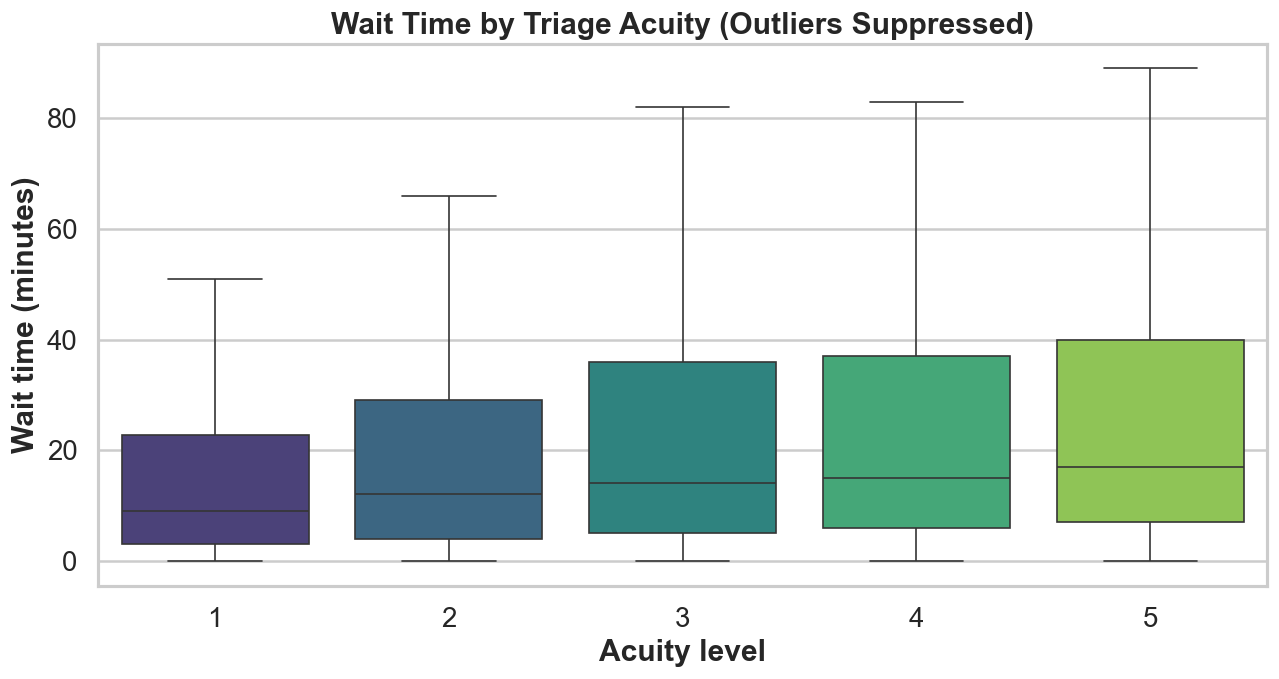

In [36]:
plot_df = df[["target_triage_acuity", "wait_time_minutes"]].dropna().copy()
plot_df["wait_time_minutes"] = plot_df["wait_time_minutes"].clip(upper=plot_df["wait_time_minutes"].quantile(0.99))

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=plot_df,
    x="target_triage_acuity",
    y="wait_time_minutes",
    palette="viridis",
    showfliers=False,
    ax=ax,
 )
ax.set_title("Wait Time by Triage Acuity (Outliers Suppressed)")
ax.set_xlabel("Acuity level")
ax.set_ylabel("Wait time (minutes)")

save_and_show(fig, "04_wait_by_acuity_boxplot.png")

### Chart 5: Median wait trend across years
This highlights macro-level operational changes and potential period effects (for example, pandemic-era shifts).

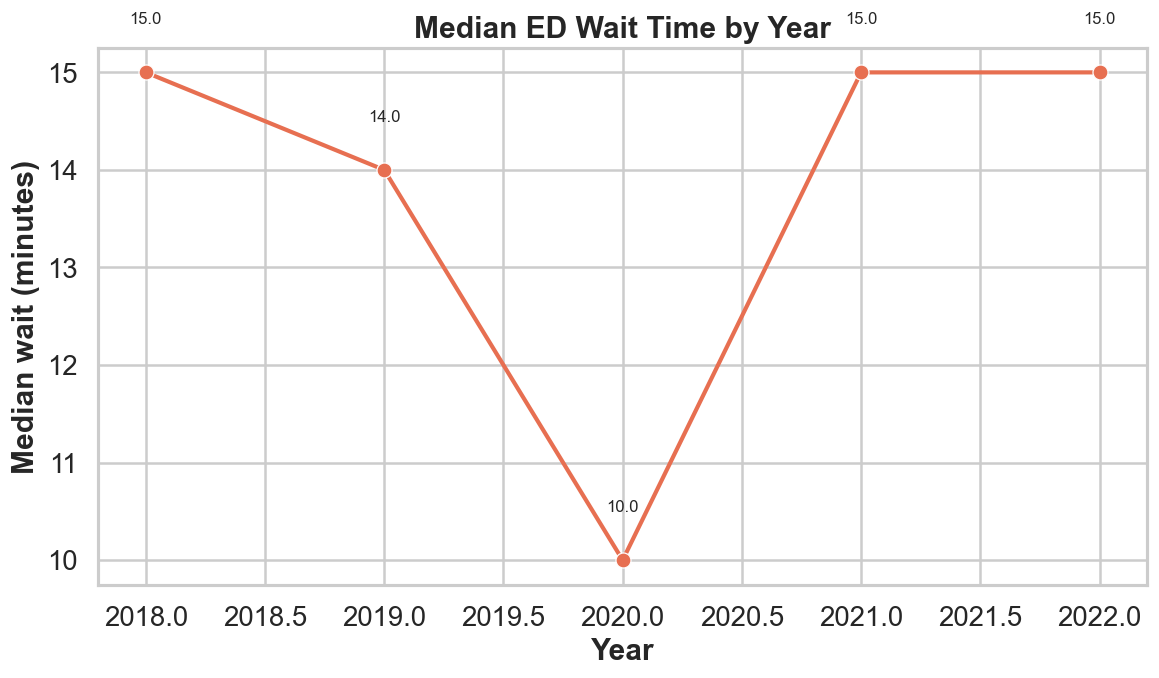

In [37]:
year_wait = df.groupby("year", as_index=False)["wait_time_minutes"].median()

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=year_wait, x="year", y="wait_time_minutes", marker="o", linewidth=2.5, color="#e76f51", ax=ax)
ax.set_title("Median ED Wait Time by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Median wait (minutes)")

for _, row in year_wait.iterrows():
    ax.text(row["year"], row["wait_time_minutes"] + 0.5, f"{row['wait_time_minutes']:.1f}", ha="center", fontsize=10)

save_and_show(fig, "05_median_wait_by_year.png")

### Chart 6: Year x acuity median wait heatmap
This interaction view shows whether changes over years are uniform across severity bands.

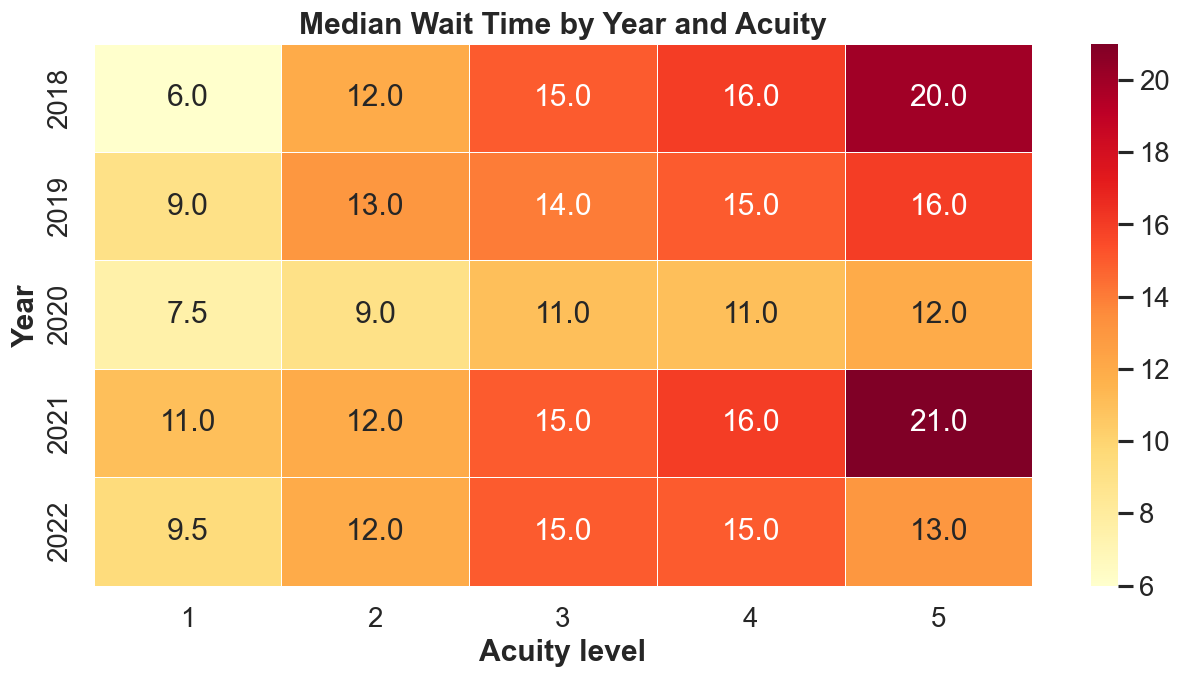

In [38]:
year_acuity_wait = df.pivot_table(
    index="year",
    columns="target_triage_acuity",
    values="wait_time_minutes",
    aggfunc="median",
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(year_acuity_wait, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Median Wait Time by Year and Acuity")
ax.set_xlabel("Acuity level")
ax.set_ylabel("Year")

save_and_show(fig, "06_year_acuity_wait_heatmap.png")

## 2) Temporal Demand Patterns
These charts map how ED volume and acuity vary by calendar and arrival timing.

### Chart 7: Visit volume by month
Seasonality in ED use can affect staffing and wait-time expectations.

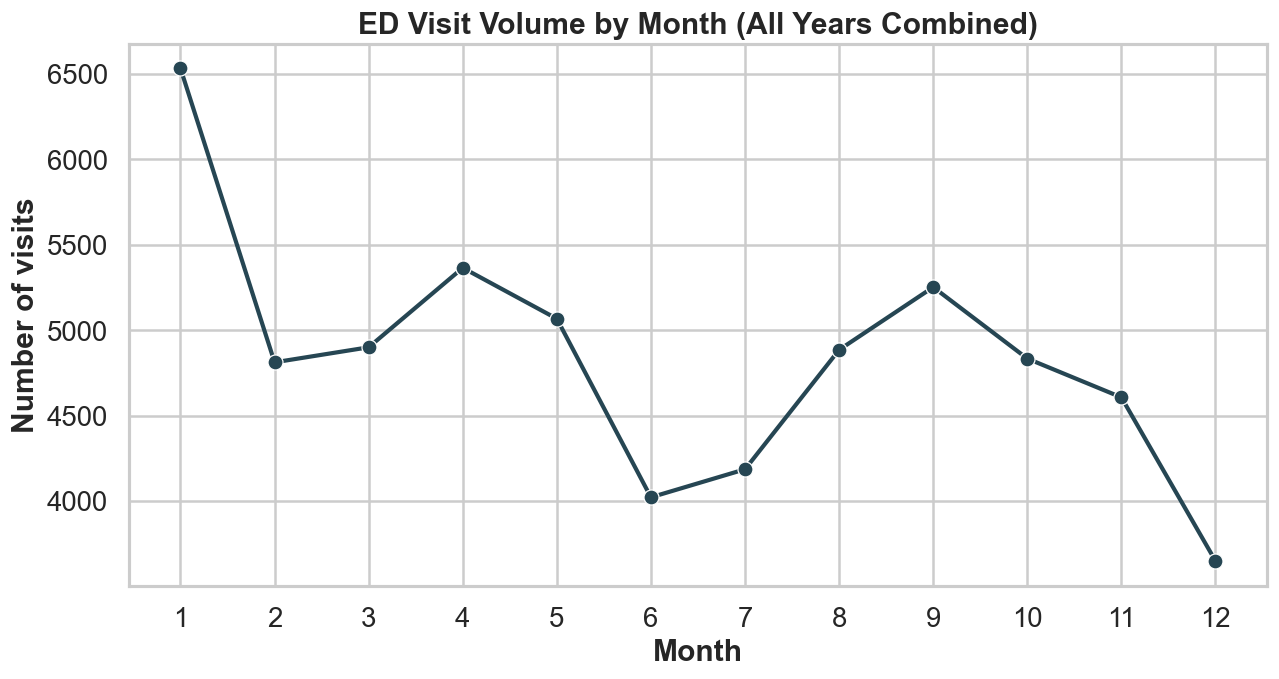

In [39]:
month_counts = df["visit_month"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(x=month_counts.index, y=month_counts.values, marker="o", linewidth=2.5, color="#264653", ax=ax)
ax.set_title("ED Visit Volume by Month (All Years Combined)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of visits")
ax.set_xticks(range(1, 13))

save_and_show(fig, "07_visit_volume_by_month.png")

### Chart 8: Visit volume by day of week
This comparison reveals weekly load concentration and potential operational bottlenecks.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\1088180636.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_counts.index, y=day_counts.values, palette="rocket", ax=ax)


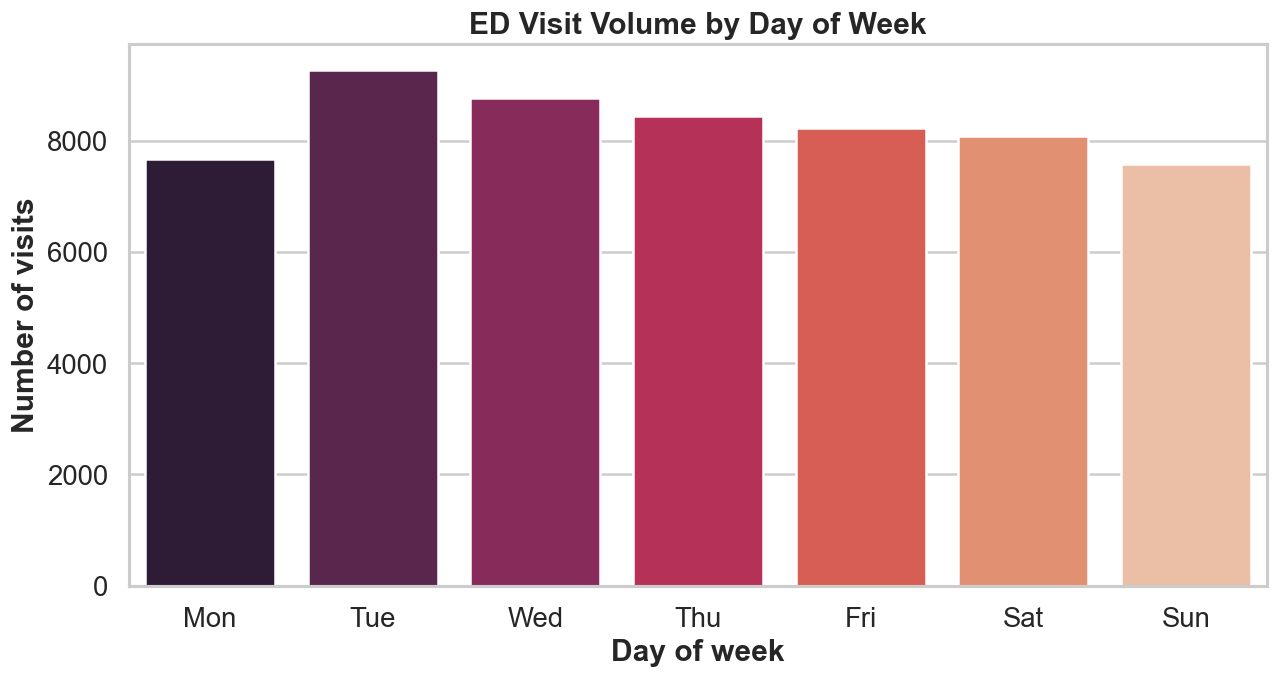

In [40]:
day_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
day_counts = df["day_of_week"].map(day_map).value_counts().reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=day_counts.index, y=day_counts.values, palette="rocket", ax=ax)
ax.set_title("ED Visit Volume by Day of Week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Number of visits")

save_and_show(fig, "08_visit_volume_by_day_of_week.png")

### Chart 9: Arrival volume by hour of day
Hourly demand highlights the intraday pressure pattern that influences ED throughput.

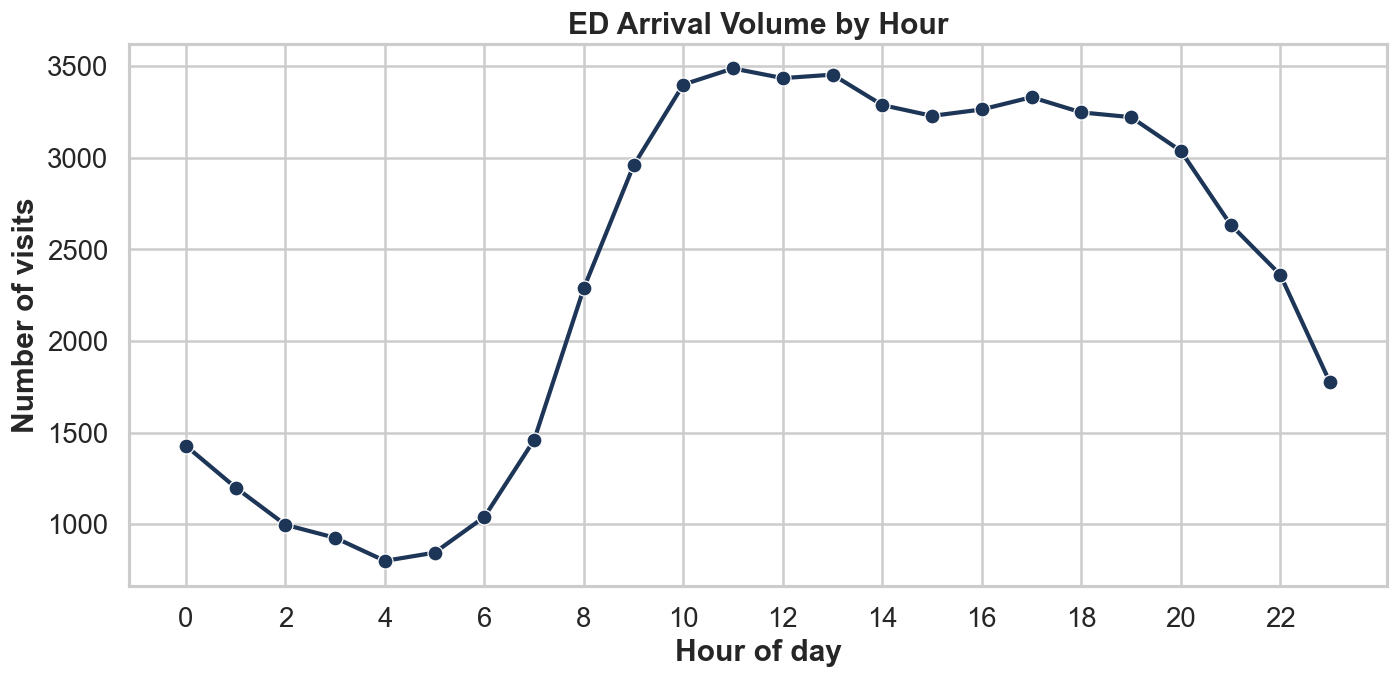

In [41]:
hour_counts = df["arrival_hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker="o", linewidth=2.5, color="#1d3557", ax=ax)
ax.set_title("ED Arrival Volume by Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of visits")
ax.set_xticks(range(0, 24, 2))

save_and_show(fig, "09_arrivals_by_hour.png")

## 3) Demographic and Fairness Comparisons
This section studies severity and wait-time disparities across key population dimensions.

### Chart 10: Age distribution by acuity
This reveals how severity mix shifts with patient age profile.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\4261066047.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


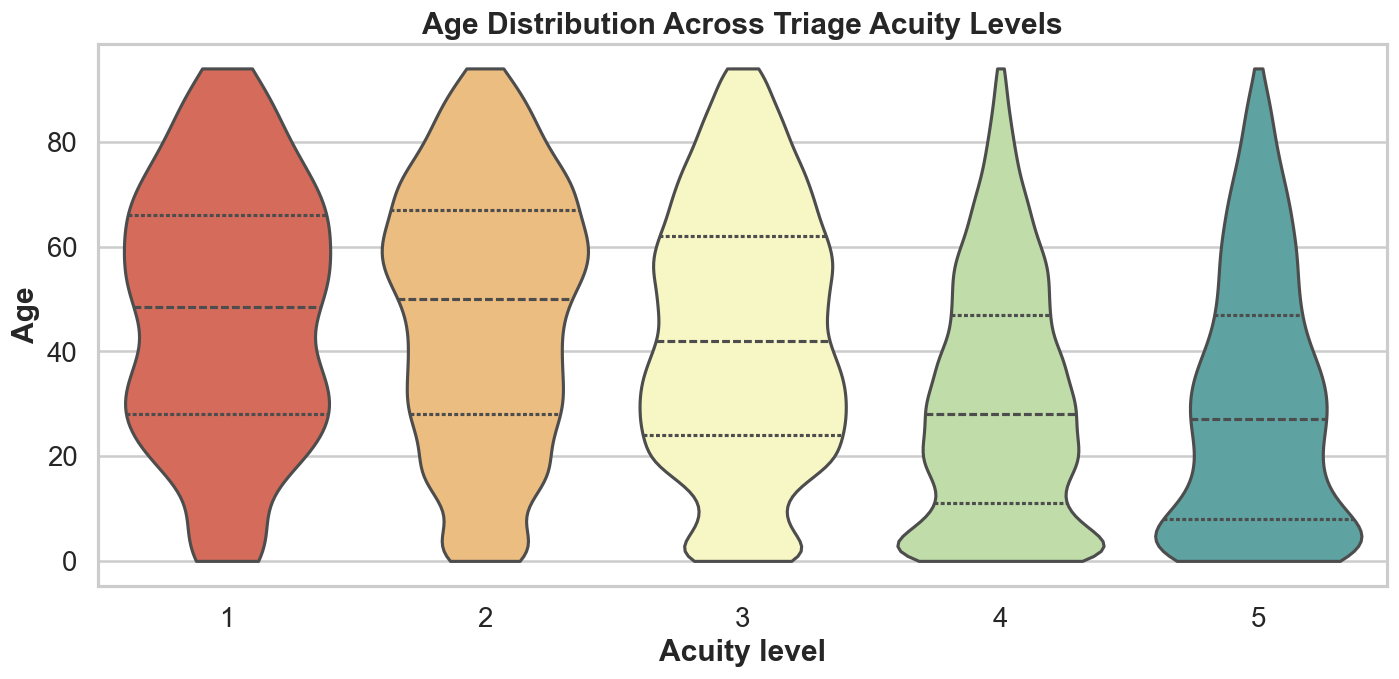

In [42]:
plot_df = df[["target_triage_acuity", "age"]].dropna()

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=plot_df,
    x="target_triage_acuity",
    y="age",
    palette="Spectral",
    cut=0,
    inner="quartile",
    ax=ax,
 )
ax.set_title("Age Distribution Across Triage Acuity Levels")
ax.set_xlabel("Acuity level")
ax.set_ylabel("Age")

save_and_show(fig, "10_age_distribution_by_acuity.png")

### Chart 11: Acuity composition by sex
Normalized composition helps compare severity mix independent of group size.

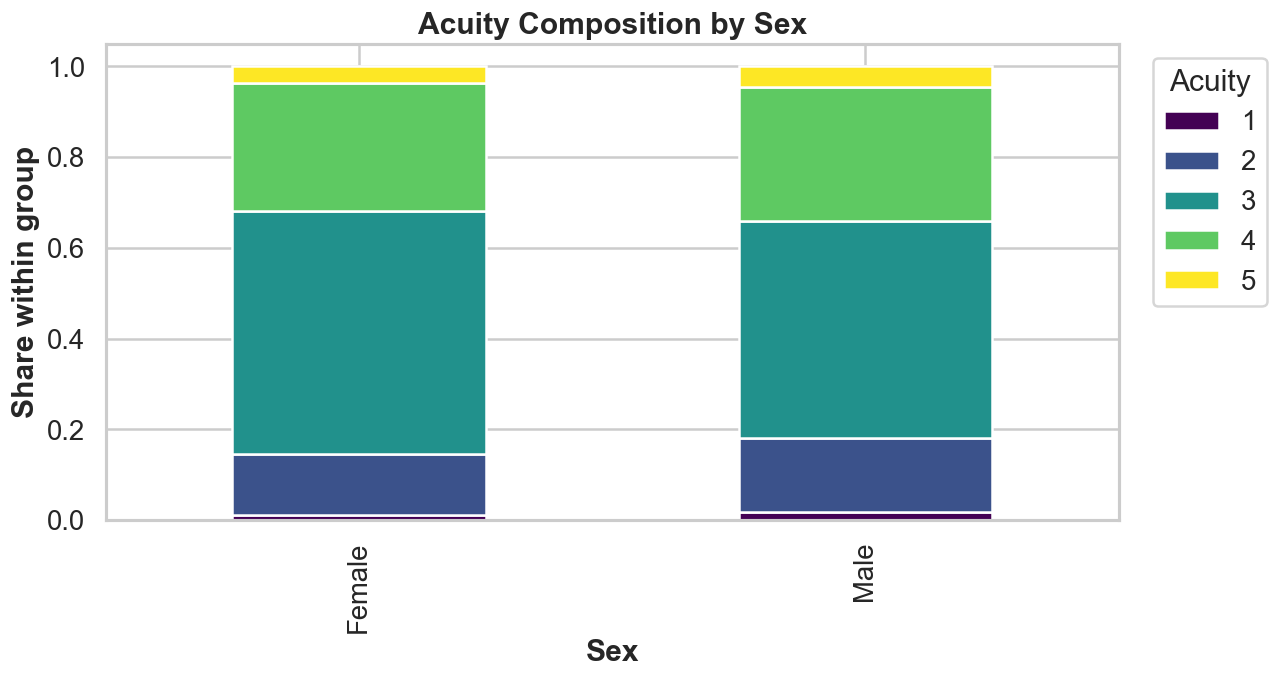

In [43]:
sex_acuity = pd.crosstab(df["sex"], df["target_triage_acuity"], normalize="index")
sex_acuity = sex_acuity.sort_index()

fig, ax = plt.subplots(figsize=(11, 6))
sex_acuity.plot(kind="bar", stacked=True, colormap="viridis", ax=ax)
ax.set_title("Acuity Composition by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Share within group")
ax.legend(title="Acuity", bbox_to_anchor=(1.02, 1), loc="upper left")

save_and_show(fig, "11_acuity_composition_by_sex.png")

### Chart 12: Median wait by race (major groups)
Comparing waits by race is central for equity diagnostics, using groups with adequate sample size.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\1619981208.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=race_wait, x="wait_time_minutes", y="race", palette="flare", ax=ax)


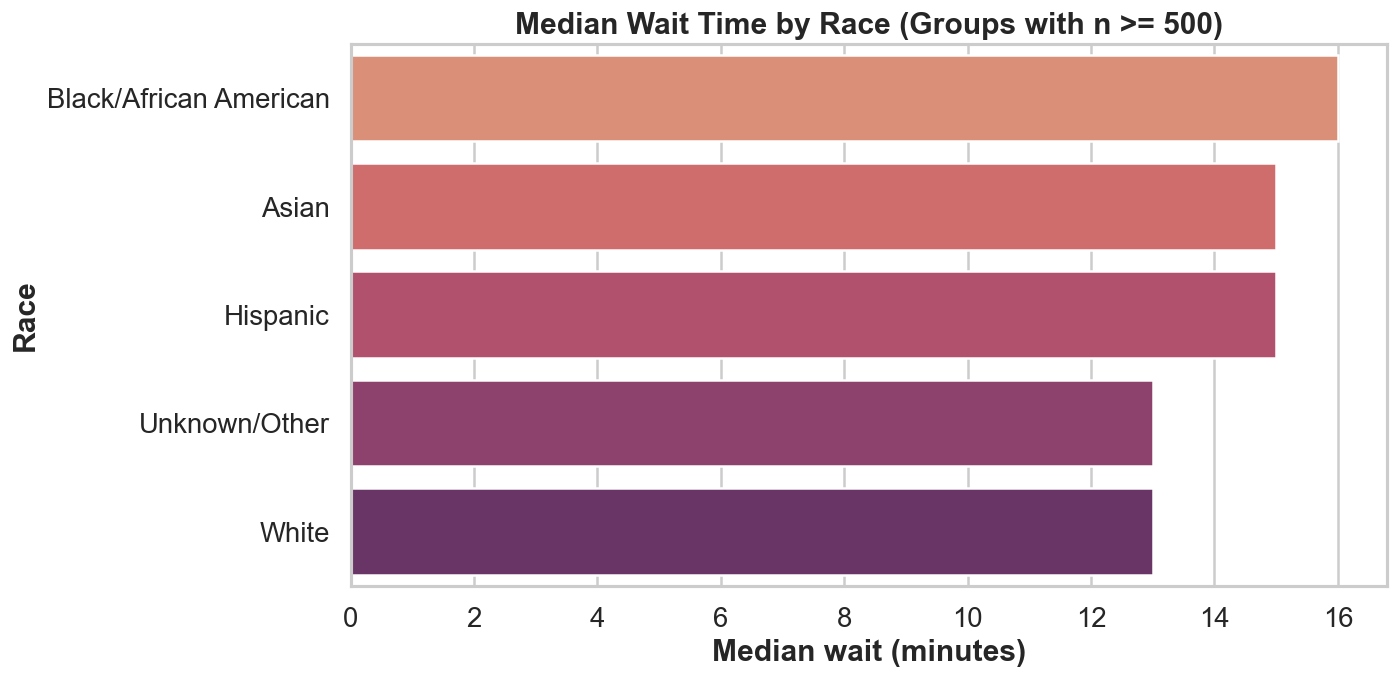

In [44]:
race_counts = df["race"].value_counts()
major_race = race_counts[race_counts >= 500].index
race_wait = (
    df[df["race"].isin(major_race)]
    .groupby("race", as_index=False)["wait_time_minutes"]
    .median()
    .sort_values("wait_time_minutes", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=race_wait, x="wait_time_minutes", y="race", palette="flare", ax=ax)
ax.set_title("Median Wait Time by Race (Groups with n >= 500)")
ax.set_xlabel("Median wait (minutes)")
ax.set_ylabel("Race")

save_and_show(fig, "12_median_wait_by_race.png")

### Chart 13: Median wait by insurance type
Coverage type can proxy both access pathway and case complexity, making it important for disparity analysis.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\1759461187.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ins_plot, x="wait_time_minutes", y="insurance_label", palette="magma", ax=ax)


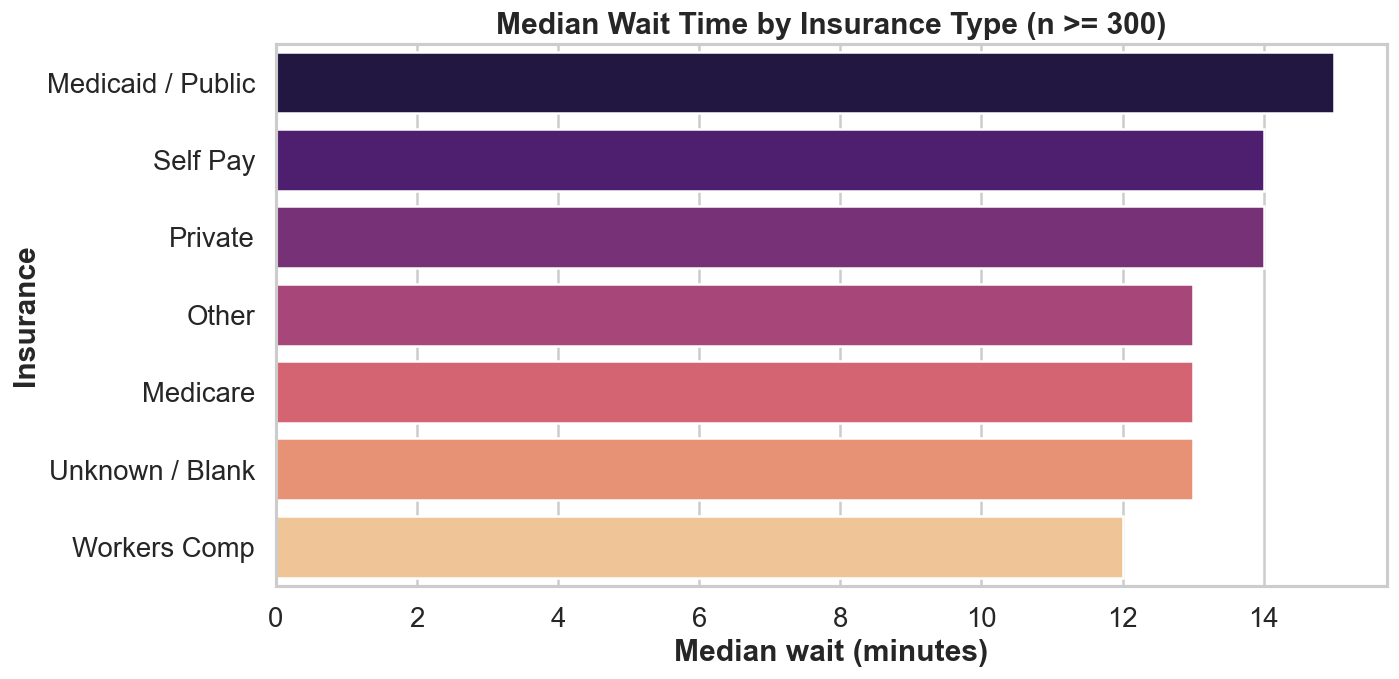

In [64]:
ins_counts = df["insurance"].value_counts()
major_ins = ins_counts[ins_counts >= 300].index
ins_wait = (
    df[df["insurance"].isin(major_ins)]
    .groupby("insurance", as_index=False)["wait_time_minutes"]
    .median()
    .sort_values("wait_time_minutes", ascending=False)
)

ins_plot = ins_wait.copy()
ins_plot["insurance_label"] = (
    ins_plot["insurance"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.replace("/", " / ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
 )
ins_plot["insurance_label"] = ins_plot["insurance_label"].replace({
    "Unknown Blank": "Unknown / Blank",
})
ins_plot = (
    ins_plot.groupby("insurance_label", as_index=False)["wait_time_minutes"]
    .median()
    .sort_values("wait_time_minutes", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=ins_plot, x="wait_time_minutes", y="insurance_label", palette="magma", ax=ax)
ax.set_title("Median Wait Time by Insurance Type (n >= 300)")
ax.set_xlabel("Median wait (minutes)")
ax.set_ylabel("Insurance")

save_and_show(fig, "13_median_wait_by_insurance.png")

### Chart 14: High-acuity rate by age group
This reveals whether severe presentations concentrate in older age bands.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\293906641.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_high, x="age_group", y="high_acuity_pct", palette="cubehelix", ax=ax)


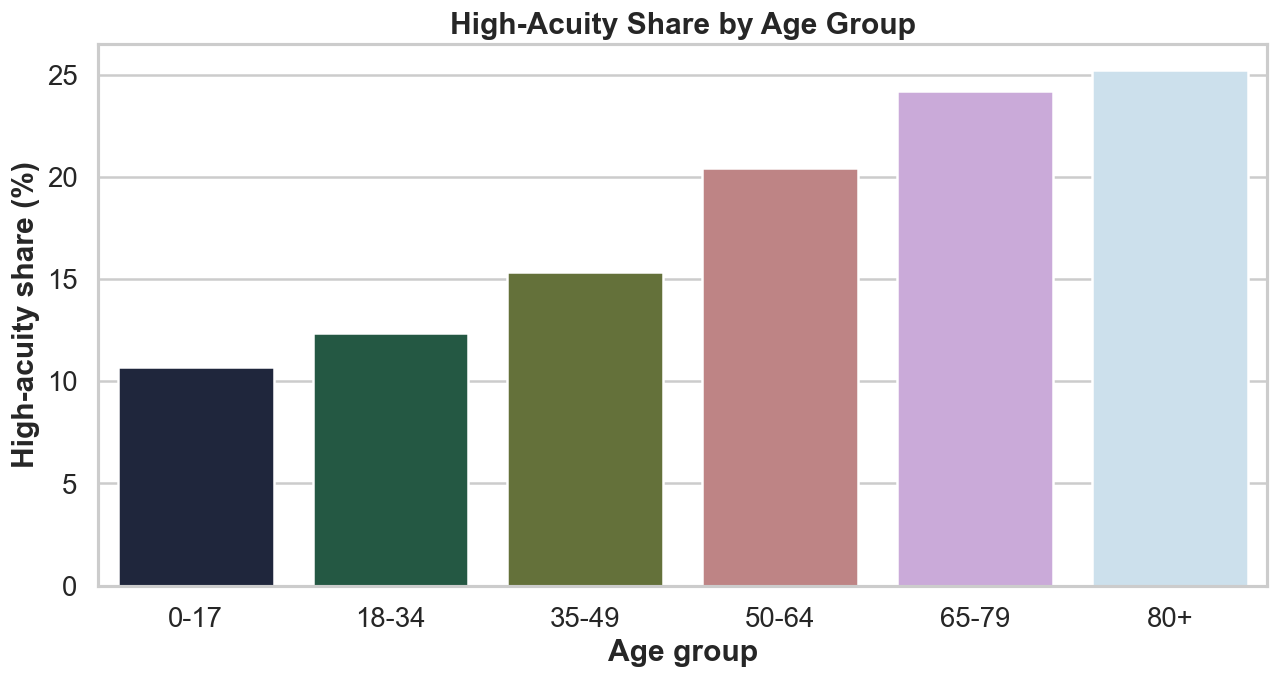

In [46]:
age_high = (
    df.groupby("age_group", observed=False)["high_acuity_flag"]
    .mean()
    .reset_index()
    .dropna()
 )
age_high["high_acuity_pct"] = age_high["high_acuity_flag"] * 100

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=age_high, x="age_group", y="high_acuity_pct", palette="cubehelix", ax=ax)
ax.set_title("High-Acuity Share by Age Group")
ax.set_xlabel("Age group")
ax.set_ylabel("High-acuity share (%)")

save_and_show(fig, "14_high_acuity_rate_by_age_group.png")

### Chart 15: Median wait heatmap by sex and race
An intersectional view helps identify whether disparity patterns differ across combined groups.

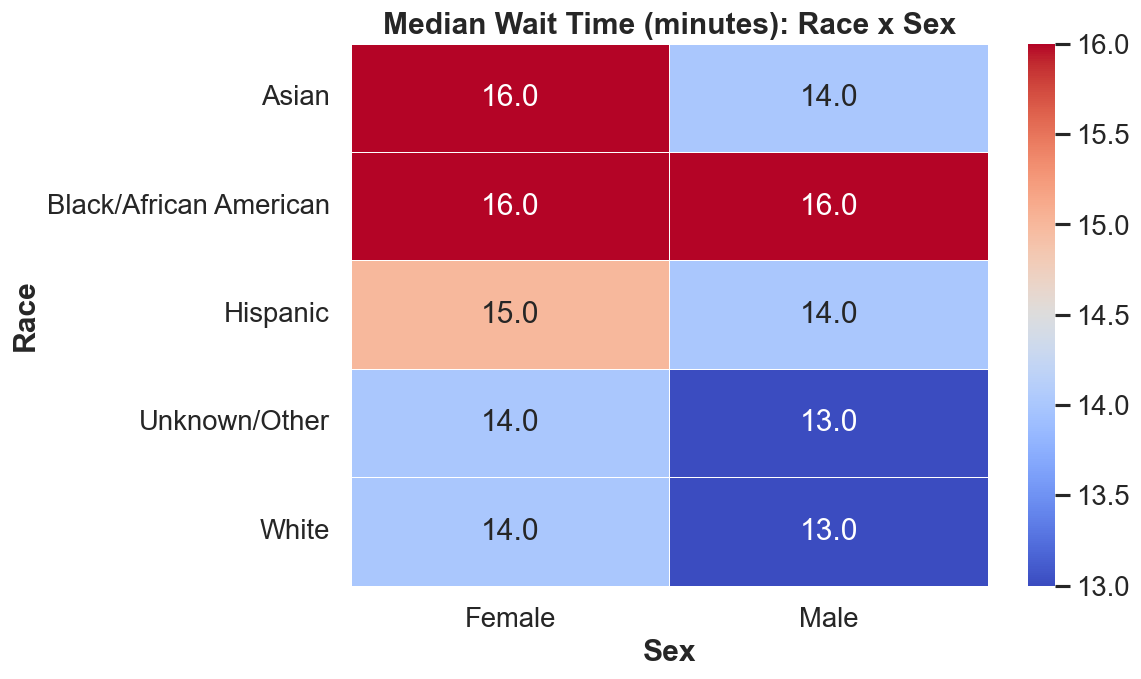

In [47]:
race_counts = df["race"].value_counts()
major_race = race_counts[race_counts >= 500].index
sex_race_wait = (
    df[df["race"].isin(major_race)]
    .pivot_table(index="race", columns="sex", values="wait_time_minutes", aggfunc="median")
 )

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(sex_race_wait, annot=True, fmt=".1f", cmap="coolwarm", linewidths=0.5, ax=ax)
ax.set_title("Median Wait Time (minutes): Race x Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Race")

save_and_show(fig, "15_wait_heatmap_race_sex.png")

## 4) Clinical Factors and Severity Signals
This section evaluates how physiologic measures and chronic burden relate to triage intensity and throughput.

### Chart 16: Median vital signs by acuity
A joint heatmap of median vitals highlights clinically coherent differences across severity levels.

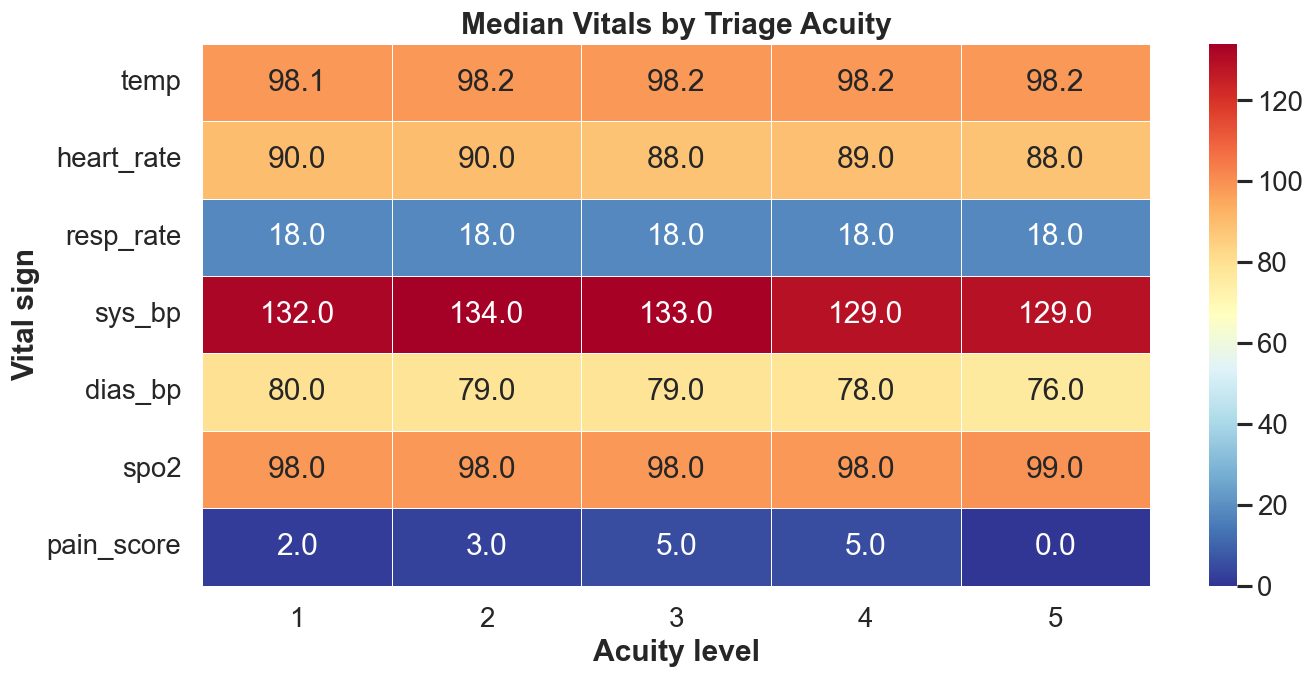

In [48]:
vital_cols = ["temp", "heart_rate", "resp_rate", "sys_bp", "dias_bp", "spo2", "pain_score"]
vital_acuity = df.groupby("target_triage_acuity")[vital_cols].median()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(vital_acuity.T, annot=True, fmt=".1f", cmap="RdYlBu_r", linewidths=0.5, ax=ax)
ax.set_title("Median Vitals by Triage Acuity")
ax.set_xlabel("Acuity level")
ax.set_ylabel("Vital sign")

save_and_show(fig, "16_median_vitals_by_acuity_heatmap.png")

### Chart 17: Pain score by acuity
Pain profile spread across acuity can reflect triage consistency and symptom burden.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\3621358493.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pain_df, x="target_triage_acuity", y="pain_score", palette="cool", showfliers=False, ax=ax)


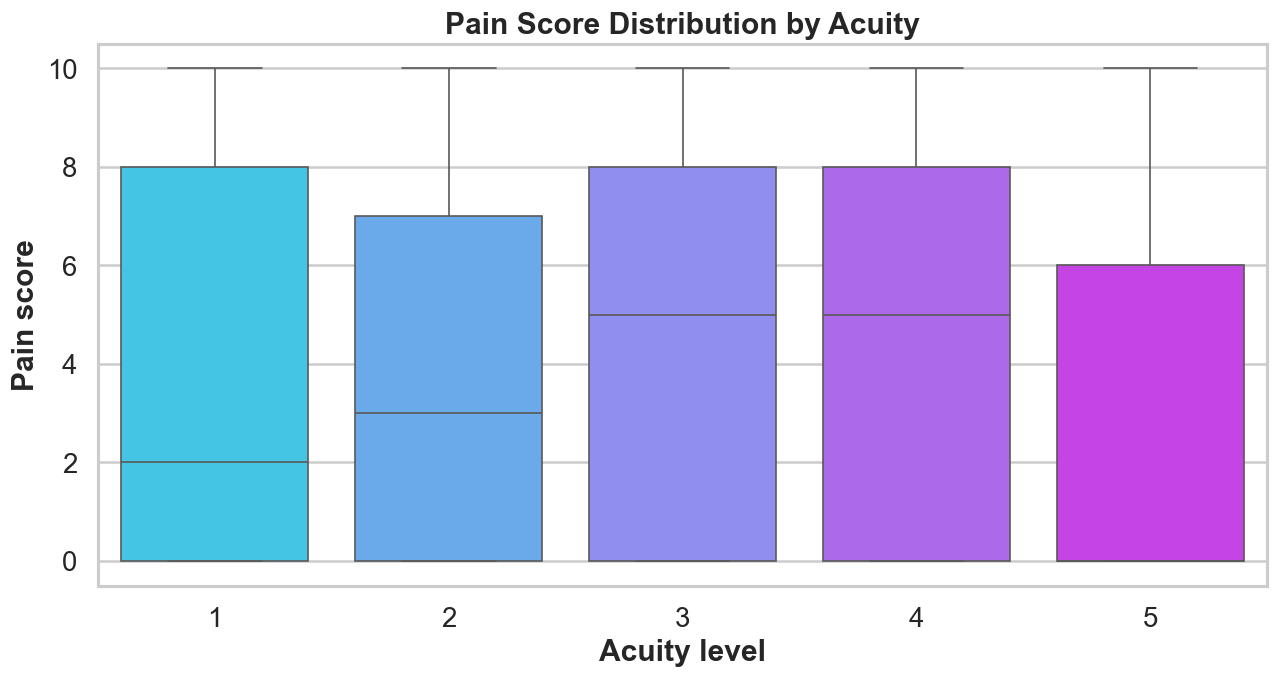

In [49]:
pain_df = df[["target_triage_acuity", "pain_score"]].dropna()

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=pain_df, x="target_triage_acuity", y="pain_score", palette="cool", showfliers=False, ax=ax)
ax.set_title("Pain Score Distribution by Acuity")
ax.set_xlabel("Acuity level")
ax.set_ylabel("Pain score")

save_and_show(fig, "17_pain_score_by_acuity.png")

### Chart 18: Top comorbidity prevalence
This profile identifies dominant chronic conditions in the observed ED population.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\2577520255.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comorb_rate.values, y=condition_labels, palette="Greens_r", ax=ax)


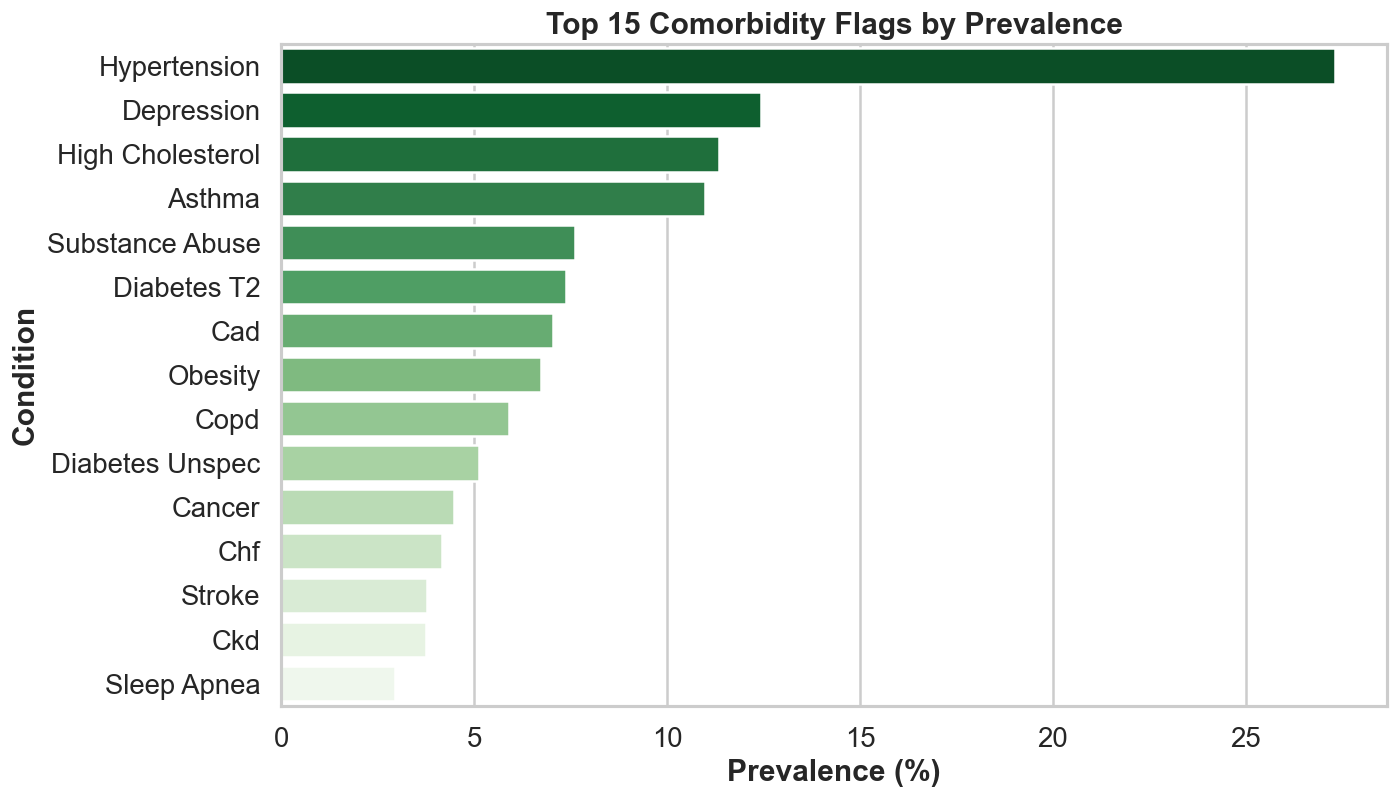

In [62]:
comorb_rate = (df[hist_cols].mean() * 100).sort_values(ascending=False).head(15)
condition_labels = (
    comorb_rate.index
    .str.replace("hist_", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
 )

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=comorb_rate.values, y=condition_labels, palette="Greens_r", ax=ax)
ax.set_title("Top 15 Comorbidity Flags by Prevalence")
ax.set_xlabel("Prevalence (%)")
ax.set_ylabel("Condition")

save_and_show(fig, "18_top_comorbidity_prevalence.png")

### Chart 19: Median wait by comorbidity burden
This checks whether larger chronic disease burden correlates with longer waits.

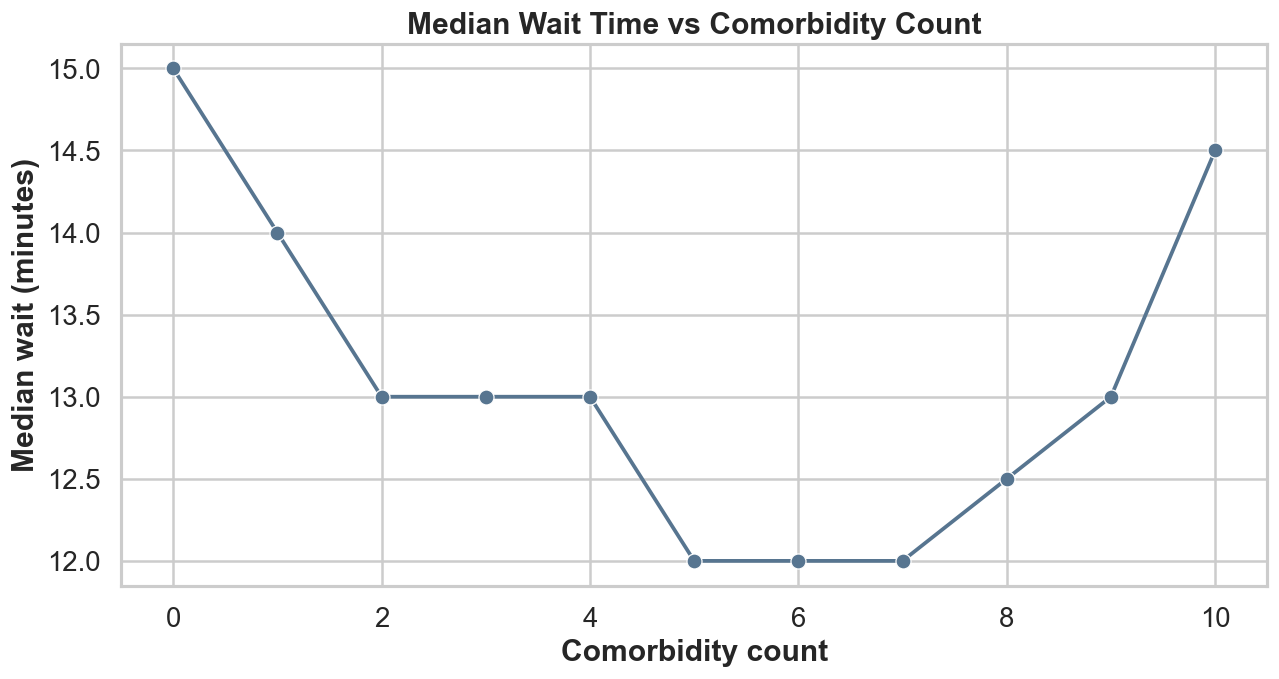

In [51]:
comorb_wait = (
    df.groupby("comorbidity_count", as_index=False)["wait_time_minutes"]
    .median()
    .query("comorbidity_count <= 10")
 )

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=comorb_wait, x="comorbidity_count", y="wait_time_minutes", marker="o", color="#577590", ax=ax)
ax.set_title("Median Wait Time vs Comorbidity Count")
ax.set_xlabel("Comorbidity count")
ax.set_ylabel("Median wait (minutes)")

save_and_show(fig, "19_wait_by_comorbidity_count.png")

### Chart 20: High-acuity share by comorbidity burden
This evaluates whether increasing chronic burden also raises severe-triage probability.

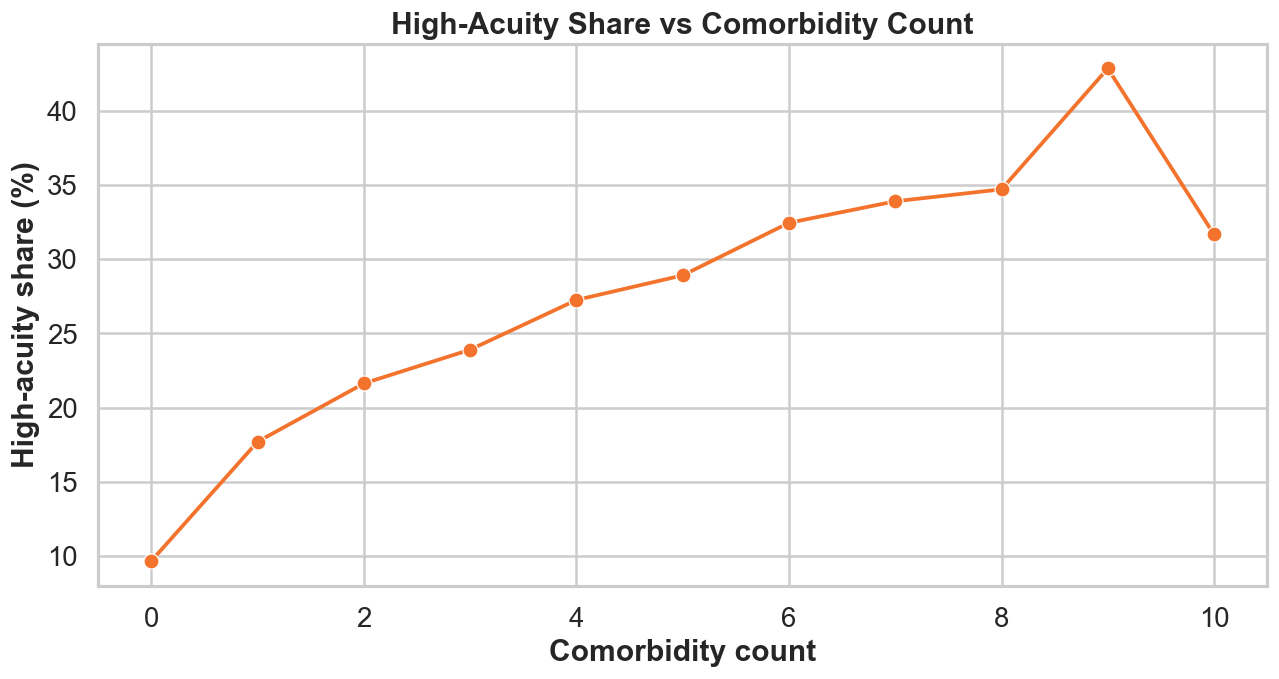

In [52]:
comorb_high = (
    df.groupby("comorbidity_count", as_index=False)["high_acuity_flag"]
    .mean()
    .query("comorbidity_count <= 10")
 )
comorb_high["high_acuity_pct"] = comorb_high["high_acuity_flag"] * 100

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=comorb_high, x="comorbidity_count", y="high_acuity_pct", marker="o", color="#f3722c", ax=ax)
ax.set_title("High-Acuity Share vs Comorbidity Count")
ax.set_xlabel("Comorbidity count")
ax.set_ylabel("High-acuity share (%)")

save_and_show(fig, "20_high_acuity_by_comorbidity_count.png")

## 5) Operational Pathways
These analyses compare throughput and severity across EMS arrival, injury context, visit episode, and intervention use.

### Chart 21: Acuity composition by EMS arrival
EMS pathway often reflects higher urgency; this plot validates that operationally.

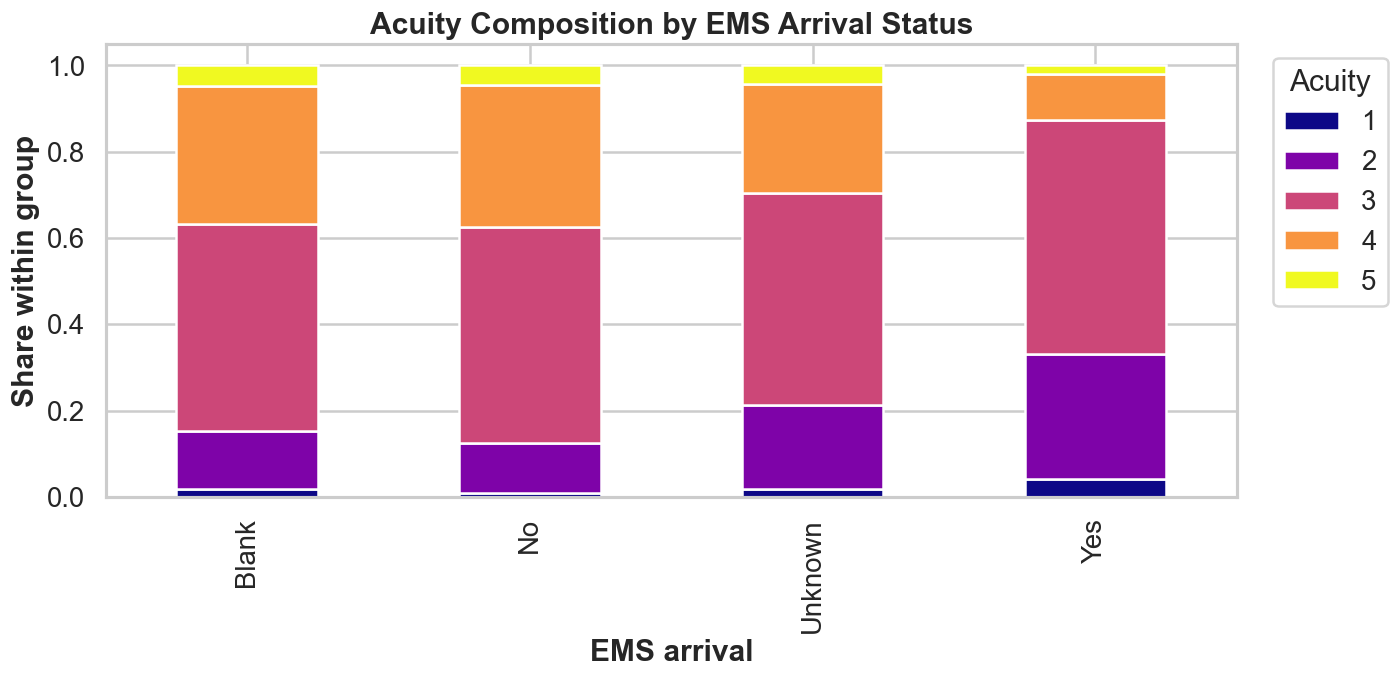

In [53]:
ems_acuity = pd.crosstab(df["ems_arrival"], df["target_triage_acuity"], normalize="index")
ems_acuity = ems_acuity.loc[ems_acuity.index.dropna()]

fig, ax = plt.subplots(figsize=(12, 6))
ems_acuity.plot(kind="bar", stacked=True, colormap="plasma", ax=ax)
ax.set_title("Acuity Composition by EMS Arrival Status")
ax.set_xlabel("EMS arrival")
ax.set_ylabel("Share within group")
ax.legend(title="Acuity", bbox_to_anchor=(1.02, 1), loc="upper left")

save_and_show(fig, "21_acuity_composition_by_ems.png")

### Chart 22: Injury and poisoning category share
This chart summarizes incident context and helps explain visit-type composition.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\322444831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=injury_counts.values, y=injury_counts.index, palette="cividis", ax=ax)


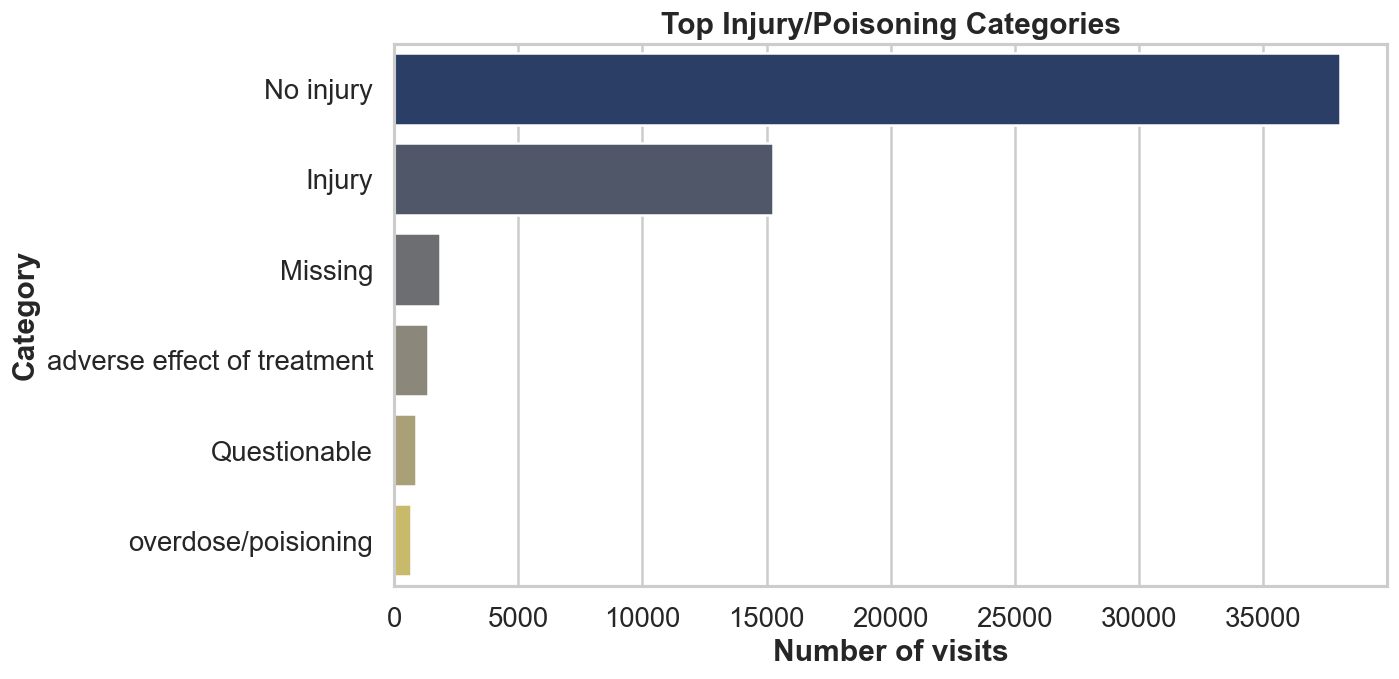

In [54]:
injury_counts = df["is_injury_poison"].fillna("Missing").value_counts().head(8)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=injury_counts.values, y=injury_counts.index, palette="cividis", ax=ax)
ax.set_title("Top Injury/Poisoning Categories")
ax.set_xlabel("Number of visits")
ax.set_ylabel("Category")

save_and_show(fig, "22_injury_poison_category_share.png")

### Chart 23: Median wait by episode type
Episode type captures repeat utilization dynamics that can influence throughput.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\3727633252.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=episode_wait, x="wait_time_minutes", y="episode", palette="viridis", ax=ax)


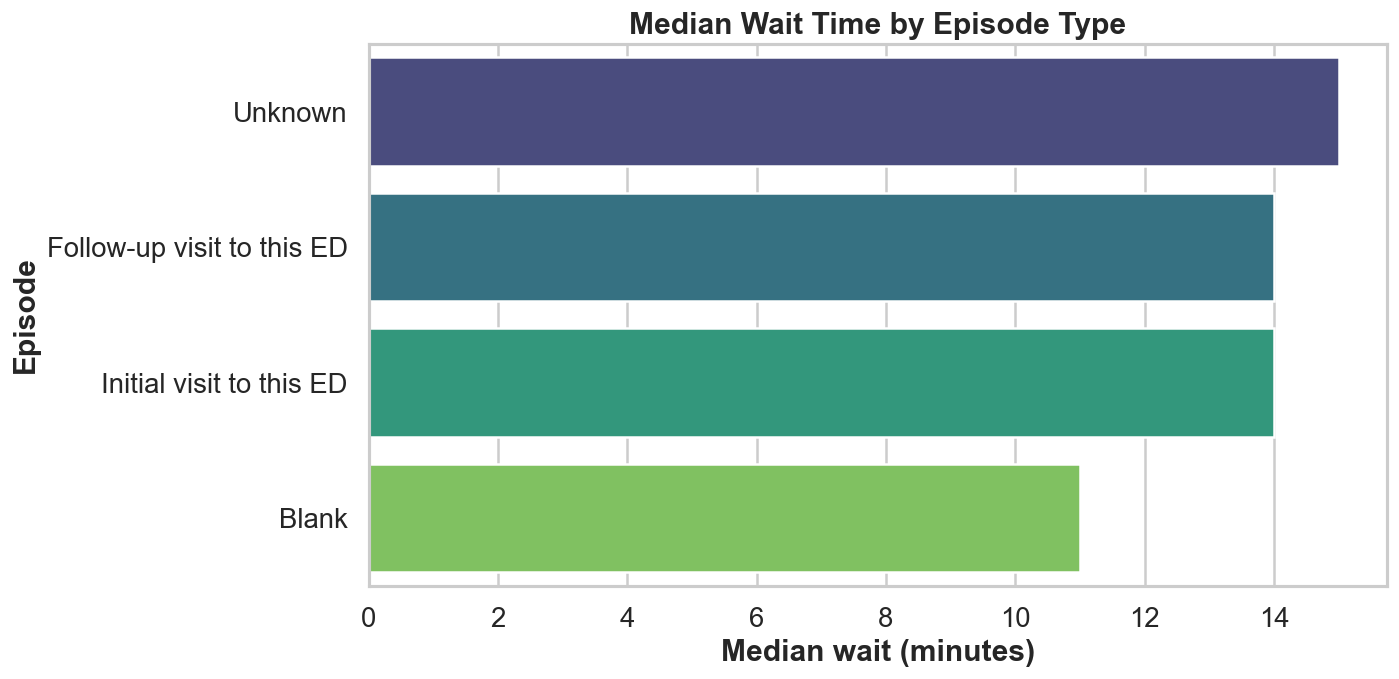

In [55]:
episode_wait = (
    df.groupby("episode", as_index=False)["wait_time_minutes"]
    .median()
    .sort_values("wait_time_minutes", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=episode_wait, x="wait_time_minutes", y="episode", palette="viridis", ax=ax)
ax.set_title("Median Wait Time by Episode Type")
ax.set_xlabel("Median wait (minutes)")
ax.set_ylabel("Episode")

save_and_show(fig, "23_median_wait_by_episode.png")

### Chart 24: IV fluids intervention rate by acuity
Intervention intensity should generally rise with severity and serves as a face-validity check.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\2455653935.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iv_rate, x="target_triage_acuity", y="iv_rate_pct", palette="icefire", ax=ax)


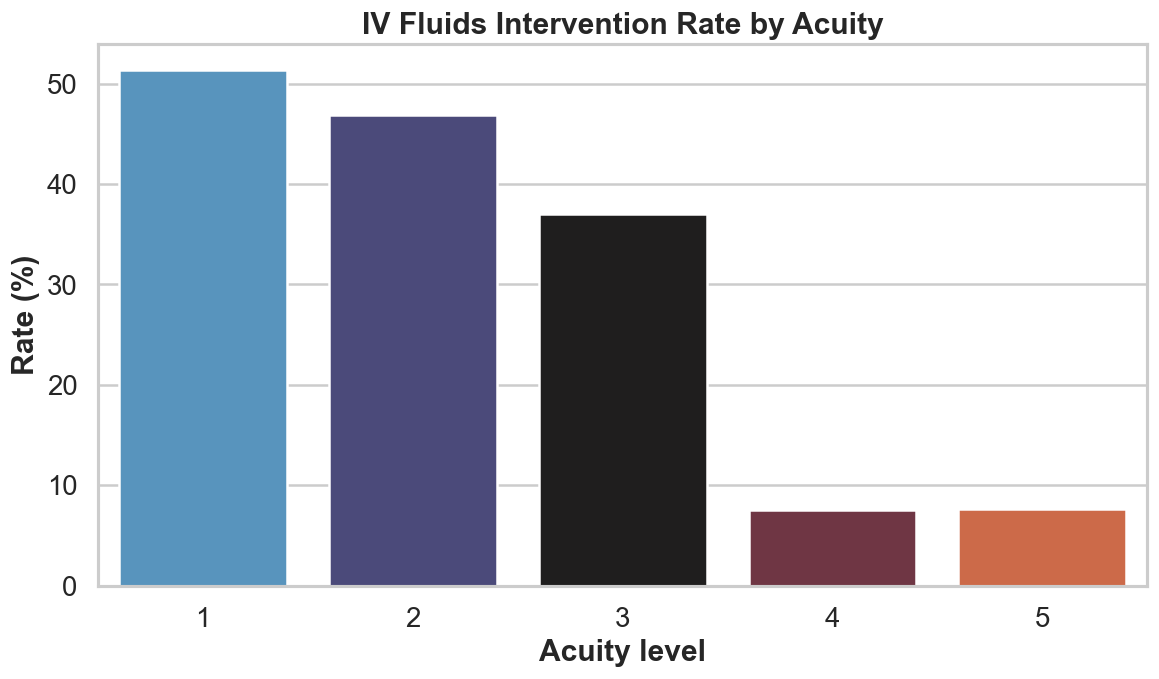

In [56]:
iv_rate = (
    df.groupby("target_triage_acuity", as_index=False)["intervention_iv_fluids"]
    .mean()
 )
iv_rate["iv_rate_pct"] = iv_rate["intervention_iv_fluids"] * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=iv_rate, x="target_triage_acuity", y="iv_rate_pct", palette="icefire", ax=ax)
ax.set_title("IV Fluids Intervention Rate by Acuity")
ax.set_xlabel("Acuity level")
ax.set_ylabel("Rate (%)")

save_and_show(fig, "24_iv_fluids_rate_by_acuity.png")

### Chart 25: Region comparison of wait vs high-acuity share
A bivariate regional plot links service pressure and severity burden in one frame.

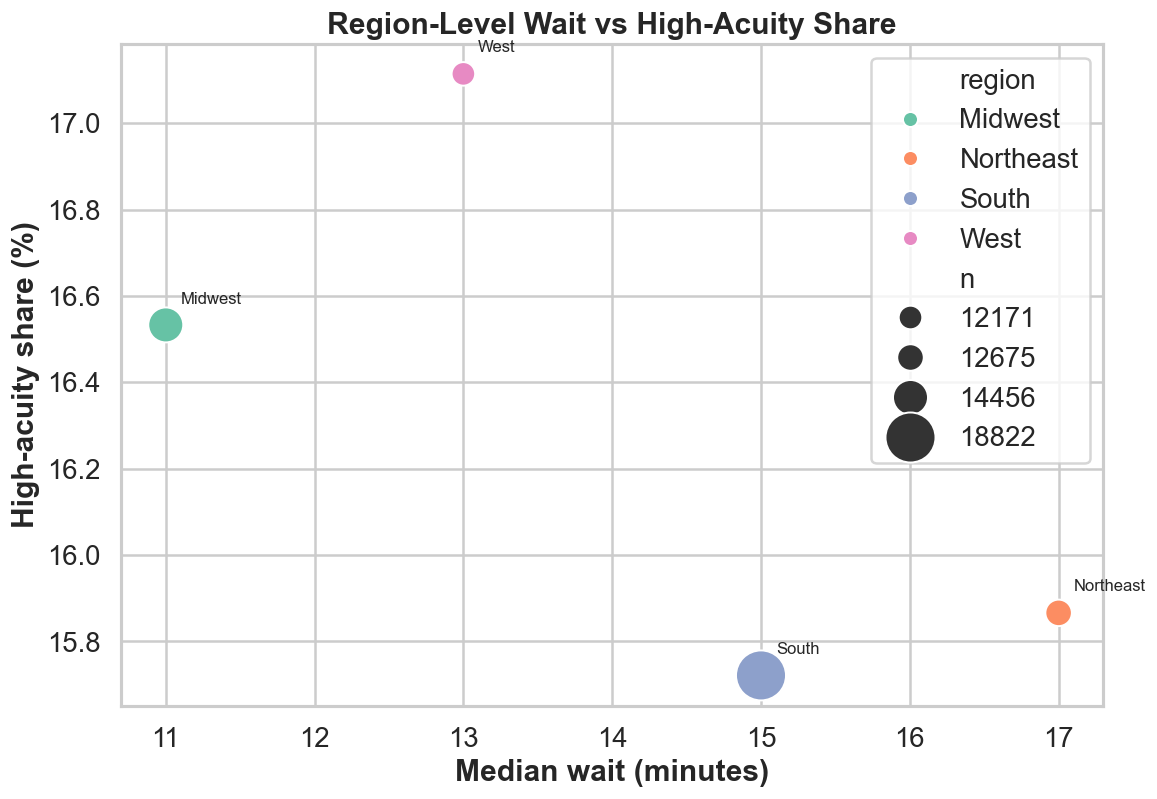

In [57]:
region_cmp = (
    df.groupby("region", as_index=False)
    .agg(
        median_wait=("wait_time_minutes", "median"),
        high_acuity_rate=("high_acuity_flag", "mean"),
        n=("region", "size"),
    )
 )
region_cmp["high_acuity_rate"] = region_cmp["high_acuity_rate"] * 100

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=region_cmp,
    x="median_wait",
    y="high_acuity_rate",
    size="n",
    hue="region",
    sizes=(200, 900),
    palette="Set2",
    ax=ax,
 )
for _, row in region_cmp.iterrows():
    ax.text(row["median_wait"] + 0.1, row["high_acuity_rate"] + 0.05, row["region"], fontsize=10)
ax.set_title("Region-Level Wait vs High-Acuity Share")
ax.set_xlabel("Median wait (minutes)")
ax.set_ylabel("High-acuity share (%)")

save_and_show(fig, "25_region_wait_vs_high_acuity_scatter.png")

## 6) Text Signals and Global Structure
These final views summarize chief complaint and injury language patterns plus numeric dependency structure.

### Chart 26: Top terms in chief complaints
Frequent complaint terms provide high-level symptom burden context for narrative framing.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\4228830767.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=complaint_terms.values, y=complaint_terms.index, palette="Blues_r", ax=ax)


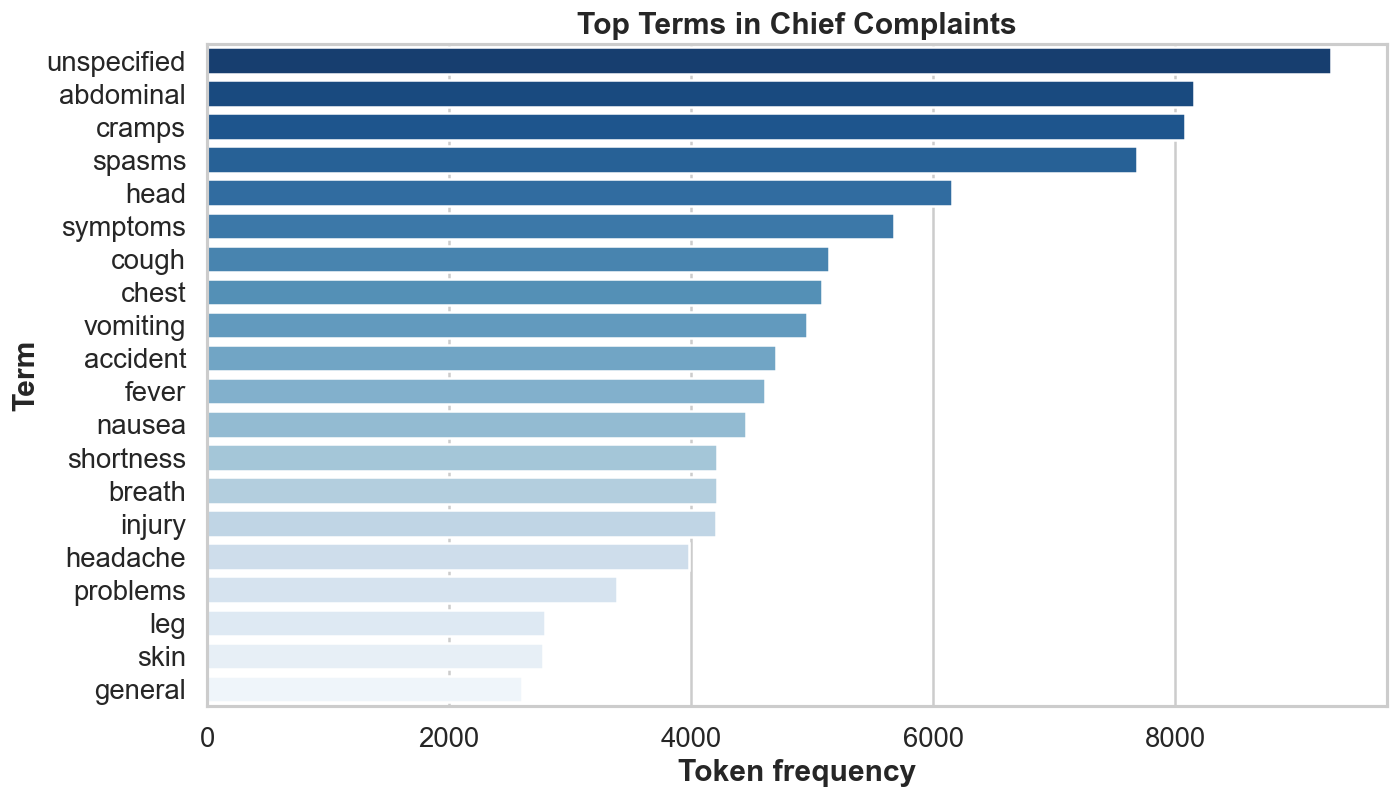

In [58]:
def top_terms(series, top_n=20):
    text = " ".join(series.dropna().astype(str).str.lower().tolist())
    tokens = re.findall(r"[a-z]{3,}", text)
    custom_stop = {"blank", "unknown", "pain", "ache", "soreness", "discomfort", "specified", "other"}
    stop = ENGLISH_STOP_WORDS.union(custom_stop)
    filtered = [t for t in tokens if t not in stop]
    return pd.Series(filtered).value_counts().head(top_n)

complaint_terms = top_terms(df["chief_complaint_text"], top_n=20)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=complaint_terms.values, y=complaint_terms.index, palette="Blues_r", ax=ax)
ax.set_title("Top Terms in Chief Complaints")
ax.set_xlabel("Token frequency")
ax.set_ylabel("Term")

save_and_show(fig, "26_top_terms_chief_complaints.png")

### Chart 27: Top terms in injury cause text
This complements complaint text with mechanism-level incident descriptors.

C:\Users\hp\AppData\Local\Temp\ipykernel_6140\858751332.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=injury_terms.values, y=injury_terms.index, palette="Oranges_r", ax=ax)


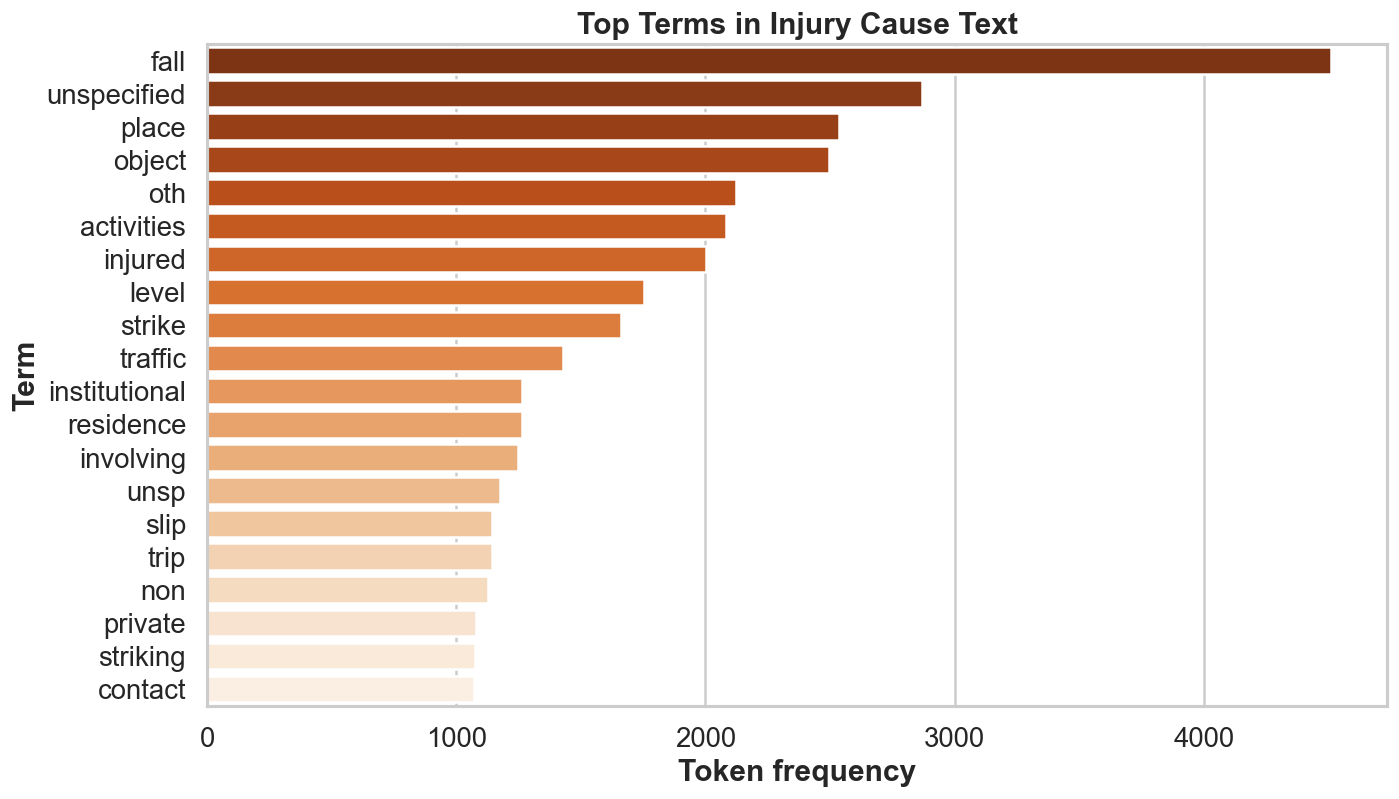

In [59]:
injury_terms = top_terms(df["injury_cause_text"], top_n=20)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=injury_terms.values, y=injury_terms.index, palette="Oranges_r", ax=ax)
ax.set_title("Top Terms in Injury Cause Text")
ax.set_xlabel("Token frequency")
ax.set_ylabel("Term")

save_and_show(fig, "27_top_terms_injury_cause.png")

### Chart 28: Correlation map of key numeric variables
This view summarizes linear associations and identifies variables that move together with waits and acuity.

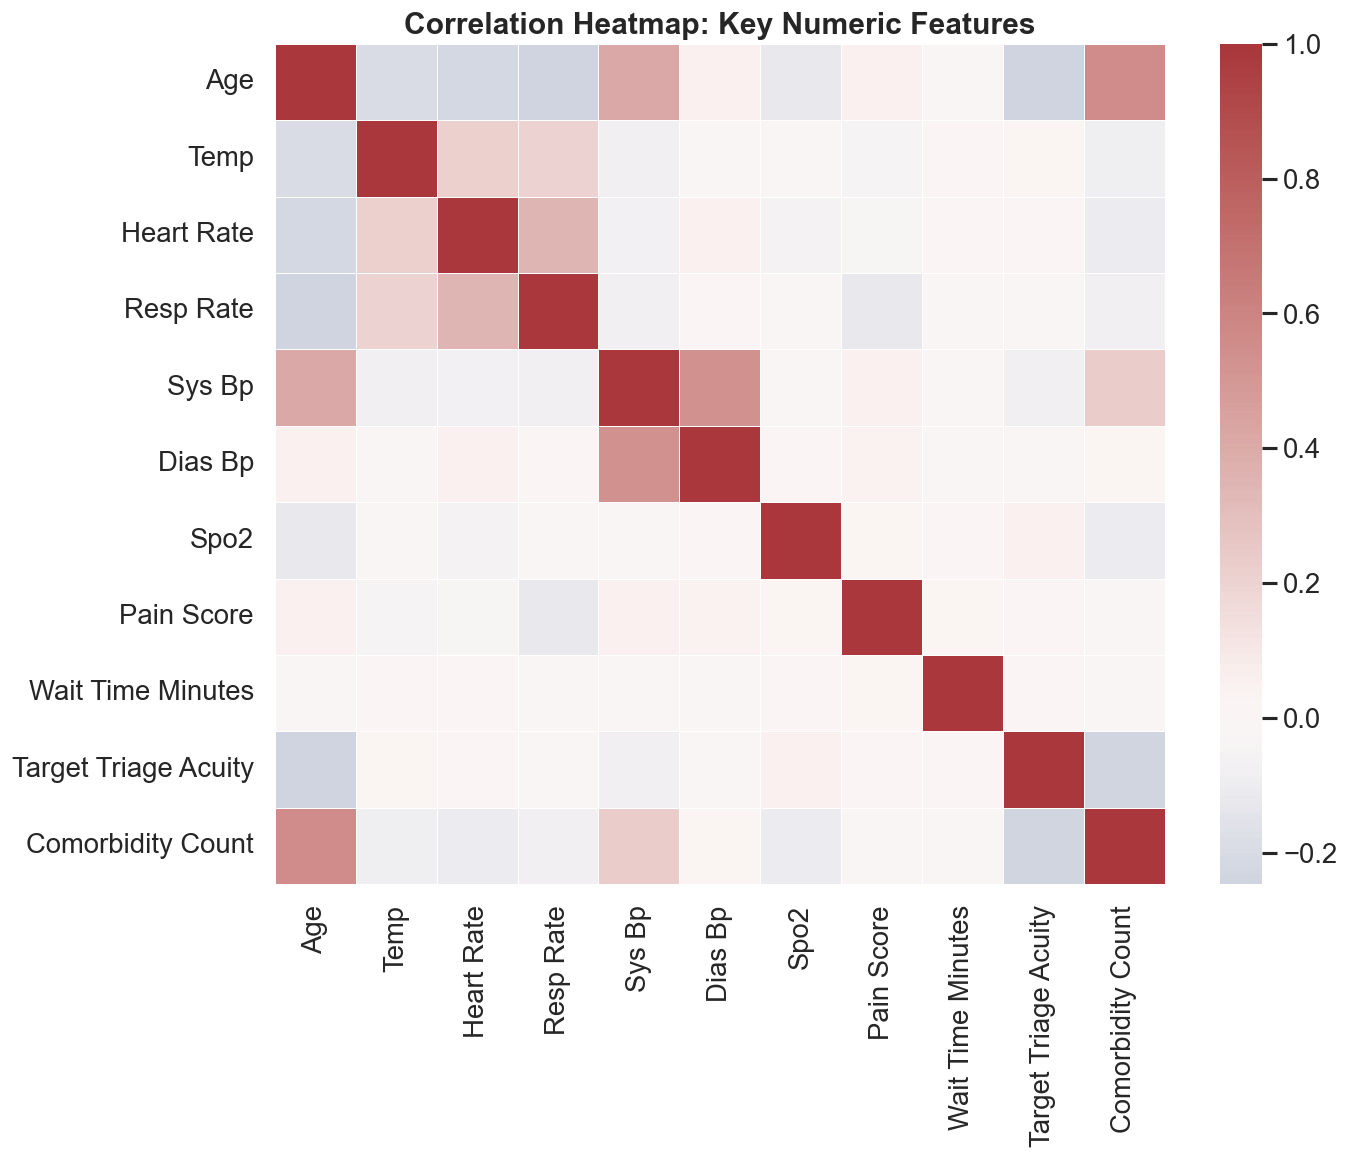

In [63]:
numeric_focus = [
    "age", "temp", "heart_rate", "resp_rate", "sys_bp", "dias_bp", "spo2", "pain_score",
    "wait_time_minutes", "target_triage_acuity", "comorbidity_count",
 ]
corr = df[numeric_focus].corr(numeric_only=True)
display_labels = [c.replace("_", " ").title() for c in numeric_focus]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="vlag", center=0, annot=False, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap: Key Numeric Features")
ax.set_xticklabels(display_labels, rotation=90)
ax.set_yticklabels(display_labels, rotation=0)

save_and_show(fig, "28_correlation_heatmap_key_numeric.png")

## 7) Synthesis for Project Writeup
### Key trends
- Class mix is concentrated in mid-acuity levels, with minority extremes requiring imbalance-aware interpretation.
- Wait-time distributions are heavily right-skewed with strong long-tail behavior.
- Year-level wait patterns suggest a clear 2020 shift with rebound in subsequent years.

### Potential bias signals
- Median wait and severity composition vary across race, insurance, sex, and age slices.
- Intersectional heatmaps indicate group-dependent disparities worth deeper causal follow-up.

### Operational implications
- EMS pathway and intervention intensity track higher acuity bands as expected.
- Episode and regional comparisons indicate distinct throughput dynamics that can inform staffing policy.

### Caveats and limitations
- Missingness is non-trivial in pain score and selected vitals, and can bias subgroup conclusions.
- These are descriptive analyses; causal claims require adjusted modeling and robustness checks.
- Text term charts are token-frequency based and do not capture context or negation.